In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import drive

# 1. Hubungkan Google Colab ke Google Drive kamu
drive.mount('/content/drive')

# 2. Amankan path direktori kompetisi INA-AI di Drive
BASE_DIR = "/content/drive/MyDrive/INA_AI_DATASET"
DATA_YAML = os.path.join(BASE_DIR, "data.yaml")

# Buat folder simpanan otomatis jika belum ada di Drive kamu
os.makedirs(BASE_DIR, exist_ok=True)

print("Google Drive berhasil terhubung.")
print(f"Konfigurasi data.yaml dibaca dari: {DATA_YAML}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive berhasil terhubung.
Konfigurasi data.yaml dibaca dari: /content/drive/MyDrive/INA_AI_DATASET/data.yaml


In [16]:
# Load pre-trained weights untuk transfer learning
model = YOLO('yolov8s.pt')

# Jalankan eksekusi training pipeline dengan output dialihkan ke Google Drive
results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    lr0=0.01,

    # === PENGALIHAN PENYIMPANAN KE GOOGLE DRIVE ===
    project=BASE_DIR,            # Output utama dialihkan ke INA_AI_Directory
    name='safezone_yolov8s_run', # Hasil akan tersimpan di INA_AI_Directory/safezone_yolov8s_run/
    exist_ok=True,               # Jika folder sudah ada, timpa isinya (mencegah duplikasi folder)

    # === PENGATURAN EARLY STOPPING ===
    patience=10,

    # === PARAMETER MITIGASI EVALUASI EDA ===
    mosaic=1.0,
    mixup=0.1,
    hsv_v=0.4
)



Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/INA_AI_DATASET/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=safezone_yolov8s_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

In [17]:
import os
import pandas as pd

# Path log hasil training yang sekarang berada di dalam Google Drive
log_path = "/content/drive/MyDrive/INA_AI_DATASET/safezone_yolov8s_run/results.csv"

if os.path.exists(log_path):
    df_results = pd.read_csv(log_path)
    # Bersihkan karakter spasi liar pada header kolom bawaan Ultralytics
    df_results.columns = df_results.columns.str.strip()

    print("=== METRIK FINAL TRAINING YOLOV8 (FROM GOOGLE DRIVE) ===")
    final_epoch = df_results.iloc[-1]
    print(f"Epoch Terakhir     : {int(final_epoch['epoch'])}")
    print(f"Train Box Loss     : {final_epoch['train/box_loss']:.4f}")
    print(f"Validation Box Loss: {final_epoch['val/box_loss']:.4f}")
    print(f"mAP50 (Global)     : {final_epoch['metrics/mAP50(B)']:.4f}")
    print(f"mAP50-95 (Precise) : {final_epoch['metrics/mAP50-95(B)']:.4f}")
else:
    print(f"CRITICAL ERROR: File results.csv tidak ditemukan di: {log_path}")
    print("Pastikan proses training di Sel 2 sudah berjalan minimal 1 epoch.")

=== METRIK FINAL TRAINING YOLOV8 (FROM GOOGLE DRIVE) ===
Epoch Terakhir     : 50
Train Box Loss     : 0.9335
Validation Box Loss: 1.1042
mAP50 (Global)     : 0.9217
mAP50-95 (Precise) : 0.6122


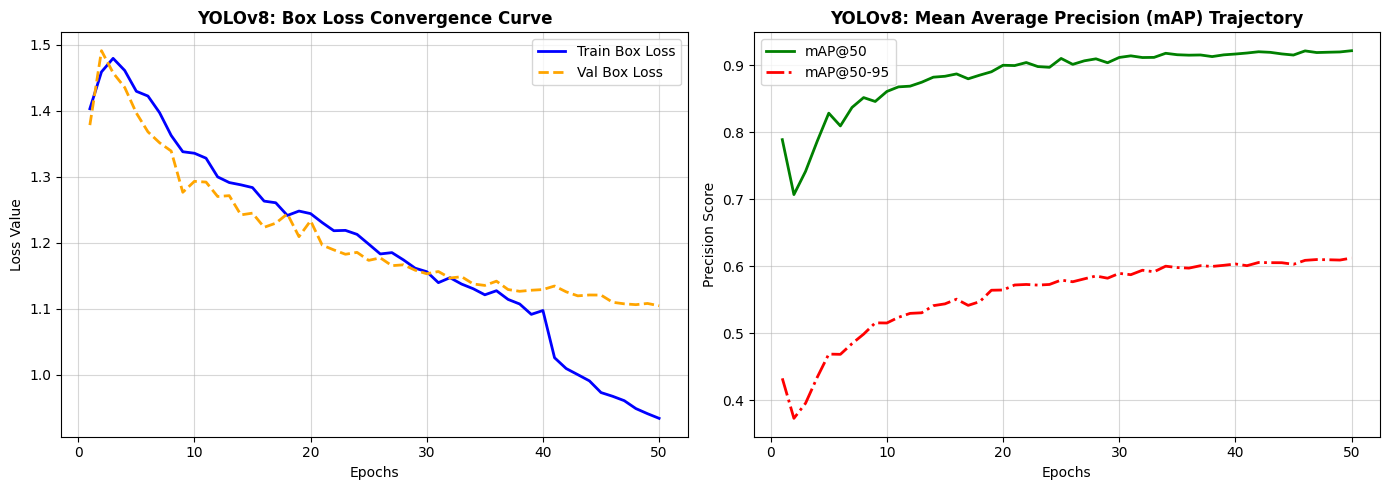

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.exists(log_path):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Grafik 1: Box Loss Convergence
    ax[0].plot(df_results['epoch'], df_results['train/box_loss'], label='Train Box Loss', color='blue', lw=2)
    ax[0].plot(df_results['epoch'], df_results['val/box_loss'], label='Val Box Loss', color='orange', linestyle='--', lw=2)
    ax[0].set_title('YOLOv8: Box Loss Convergence Curve', fontsize=12, fontweight='bold')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss Value')
    ax[0].legend()
    ax[0].grid(True, alpha=0.5)

    # Grafik 2: mAP Trajectory
    ax[1].plot(df_results['epoch'], df_results['metrics/mAP50(B)'], label='mAP@50', color='green', lw=2)
    ax[1].plot(df_results['epoch'], df_results['metrics/mAP50-95(B)'], label='mAP@50-95', color='red', linestyle='-.', lw=2)
    ax[1].set_title('YOLOv8: Mean Average Precision (mAP) Trajectory', fontsize=12, fontweight='bold')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Precision Score')
    ax[1].legend()
    ax[1].grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

In [19]:
# Path file bobot terbaik yang tersimpan aman di Google Drive kamu
best_model_path = "/content/drive/MyDrive/INA_AI_DATASET/safezone_yolov8s_run/weights/best.pt"

if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)

    print("Memulai integrasi ekspor model ke format produksi (ONNX)...")
    # Export model dengan optimasi grafik penyederhanaan arsitektur
    onnx_path = best_model.export(format='onnx', simplify=True)

    print("\n=== DEPLOYMENT ASSET SECURE ===")
    print(f"File ONNX berhasil diproduksi dan tersimpan di Google Drive: {onnx_path}")
else:
    print(f"CRITICAL ERROR: Bobot best.pt tidak ditemukan di: {best_model_path}")
    print("Selesaikan proses training di Sel 2 terlebih dahulu.")

Memulai integrasi ekspor model ke format produksi (ONNX)...
Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/INA_AI_DATASET/safezone_yolov8s_run/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 385ms
Prepared 4 packages in 1.81s
Installed 4 packages in 383ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for u